# Neutrino Interaction length in water
Auxiliary script to plot the interaction length of neutrinos in water as computed from the cross-sections provided


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
import report_plotstyle

In [2]:
filename_nu = 'Xsec_UHEnu.dat'
energy, Xsec_CC, Xsec_NC, y_CC, y_NC = np.loadtxt(filename_nu, usecols=(0,1,2,3,4), unpack=True, skiprows=2) # cm^-2

In [3]:
rho           = 1               # g / cm^3
MH2O          = 18.01528        # g / mol
NA            = 6.02214076e23   # 1 / mol
NNucleons     = 18              # 1 / molecule

n             = (rho / MH2O) * NA * NNucleons
lambda_CC_km  = 1 / (n * Xsec_CC) * 1e-2 * 1e-3
lambda_NC_km  = 1 / (n * Xsec_NC) * 1e-2 * 1e-3


## Print and plot interaction lengths in water

E = 1e1 GeV; L_CC = 213893009 km, L_NC = 686755653 km 
E = 1e2 GeV; L_CC = 23844314 km, L_NC = 76587497 km 
E = 1e3 GeV; L_CC = 2659118 km, L_NC = 8351501 km 
E = 1e4 GeV; L_CC = 366068 km, L_NC = 1072225 km 
E = 1e5 GeV; L_CC = 84793 km, L_NC = 223080 km 
E = 1e6 GeV; L_CC = 27200 km, L_NC = 65950 km 
E = 1e7 GeV; L_CC = 9443 km, L_NC = 22219 km 
E = 1e8 GeV; L_CC = 3477 km, L_NC = 8029 km 
E = 1e9 GeV; L_CC = 1351 km, L_NC = 3078 km 
E = 1e10 GeV; L_CC = 552 km, L_NC = 1240 km 
E = 1e11 GeV; L_CC = 235 km, L_NC = 526 km 
E = 1e12 GeV; L_CC = 105 km, L_NC = 232 km 


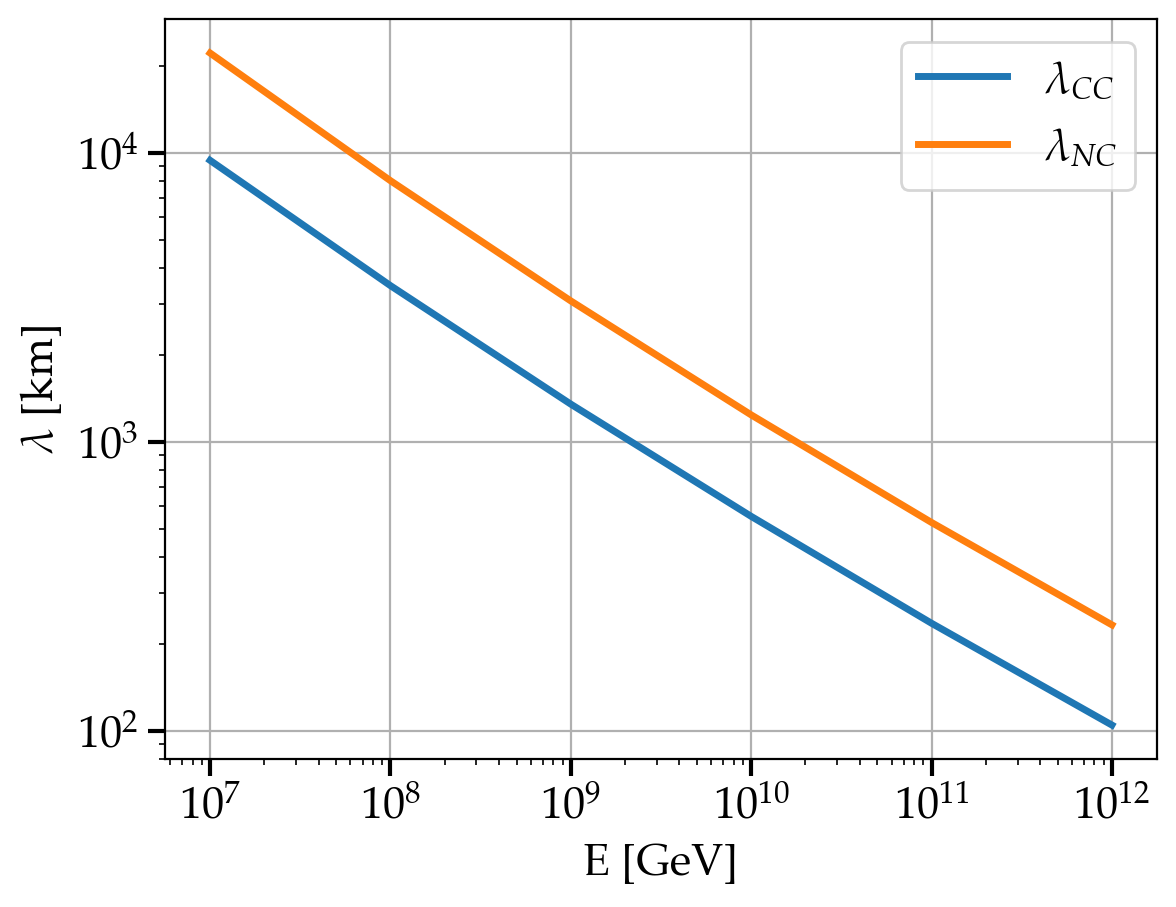

In [4]:
for i in range(len(energy)):
  print(rf"E = 1e{int(np.log10(energy[i]))} GeV; L_CC = {lambda_CC_km[i]:.0f} km, L_NC = {lambda_NC_km[i]:.0f} km ")

plt.figure()
plt.loglog(energy[6:], lambda_CC_km[6:], '-', label=r"$\lambda_{CC}$")
plt.loglog(energy[6:], lambda_NC_km[6:], '-', label=r"$\lambda_{NC}$")
plt.xlabel("E [GeV]")
plt.ylabel(r"$\lambda$ [km]")
plt.legend()
plt.grid()

# Compute angle corresponding to lambda

NOTE: this is computed for water density, so it is not correct for neutrinos traversing through the solid part of the earth

Text(0, 0.5, '$\\theta_{\\lambda}$ [$^{\\text{o}}$]')

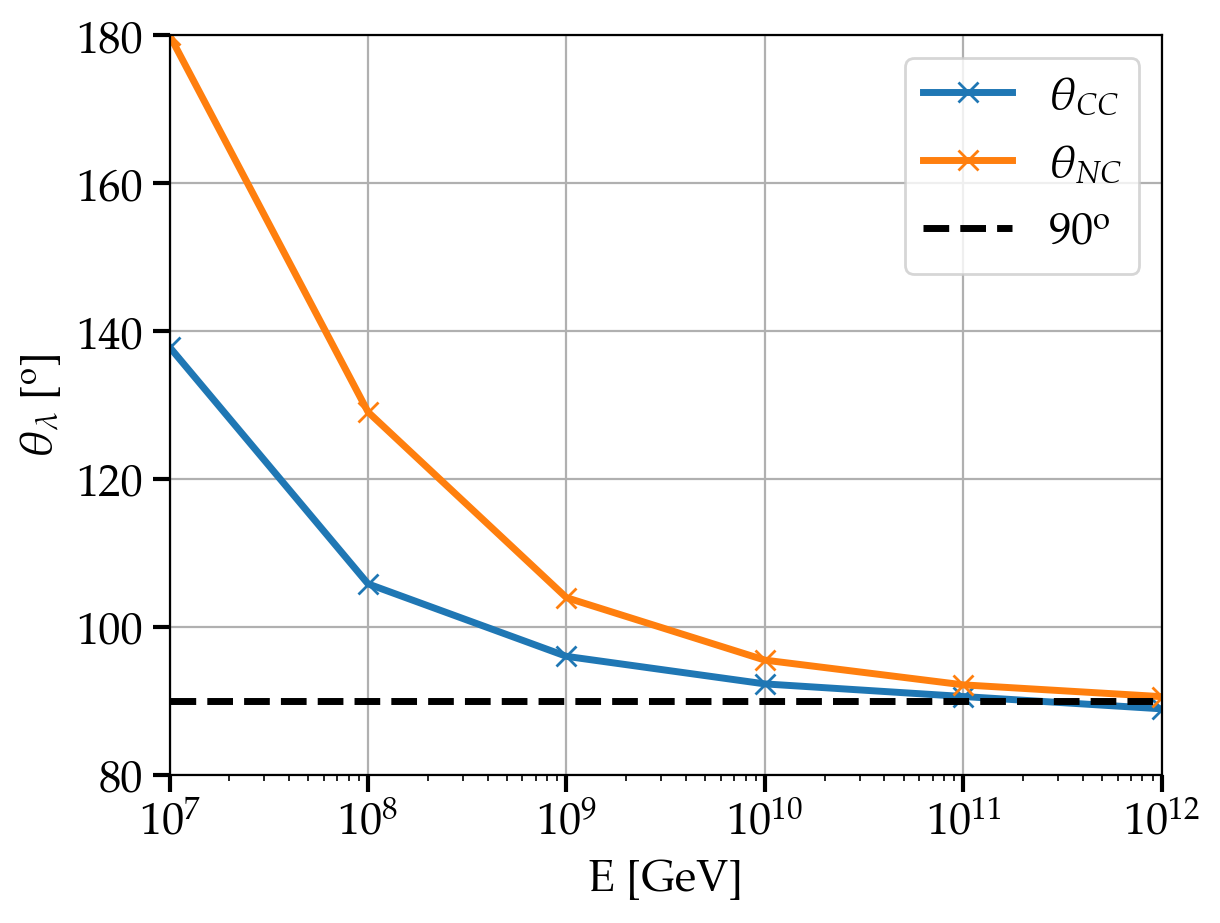

In [5]:
def zenith_angle(L):
  R = 6371       # Earth radius in km
  d = 2          # detector depth in km
  a = R - d      # detector radial distance from Earth's center

  cos_theta = np.zeros_like(L)
  smallLmask = L <= np.sqrt(R**2 - a**2)
  cos_theta[smallLmask]   = d / L[smallLmask]
  cos_theta[~smallLmask]  = (R**2 - a**2 - L[~smallLmask]**2) / (2 * a * L[~smallLmask])

  # numerical clipping to avoid floating errors
  cos_theta = np.clip(cos_theta, -1, 1)
  return np.rad2deg(np.arccos(cos_theta))

theta_NC = zenith_angle(lambda_NC_km)
theta_CC = zenith_angle(lambda_CC_km)

plt.figure()
plt.plot(energy[6:], theta_CC[6:], '-x', label=r"$\theta_{CC}$")
plt.plot(energy[6:], theta_NC[6:], '-x', label=r"$\theta_{NC}$")
plt.axhline(90, linestyle='--', c='k', label=r"90$^{\text{o}}$")
plt.xscale('log')
plt.legend()
plt.grid()
plt.xlabel("E [GeV]")
plt.xlim(1e7, 1e12)
plt.ylim(80,180)
plt.ylabel(r"$\theta_{\lambda}$ [$^{\text{o}}$]")